## MANUAL CALCULATION (WITHOUT SKLEARN)

In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [158]:
data = pd.read_csv('SLR_data.csv')
data.head()

,advertising cost,sales
0,1,15
1,2,20
2,3,28
3,4,35
4,5,45


In [159]:
print(15 * 1)
print(2 * 20)
print(28 * 3)
print(35 * 4)
print(5 * 45)

15
40
84
140
225


In [160]:
print(15 + 40 + 84 + 140 + 225)

504


In [161]:
kali = 15 * 1 + 20 * 2 + 28 * 3 + 35 * 4 + 45 * 5
print(kali)

504


In [162]:
sigma_xy = np.sum((data['advertising cost']) * (data['sales']))
print(sigma_xy)

504


In [163]:
res = np.sum(y)
print(res)
print(res / len(y))

143
28.6


In [164]:
quad = np.square(x)
print(quad)
sum_quad = np.sum(quad)
print(sum_quad)

   advertising cost
0                 1
1                 4
2                 9
3                16
4                25
advertising cost    55
dtype: int64


/home/el-system/.local/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [165]:
print(data.describe())

       advertising cost      sales
count          5.000000   5.000000
mean           3.000000  28.600000
std            1.581139  11.928956
min            1.000000  15.000000
25%            2.000000  20.000000
50%            3.000000  28.000000
75%            4.000000  35.000000
max            5.000000  45.000000


In [166]:
mean_x = np.mean(data['advertising cost'])
print(mean_x)
mean_y = np.mean(data['sales'])
print(mean_y)

3.0
28.6


In [167]:
print(15 + 40 + 84 + 140 + 255)

534


In [168]:
sigma_x = np.sum((data['advertising cost']))
sigma_y = np.sum((data['sales']))
sigma_x_kuadrat = np.sum((data['advertising cost']) ** 2)
sigma_xy = np.sum((data['advertising cost']) * (data['sales']))
print(sigma_x)
print(sigma_y)
print(sigma_x_kuadrat)
print(sigma_xy)

15
143
55
504


In [169]:
r = 5 * 504 - (15 * 143)
print(r)
t = 5 * 55 - (15 ** 2)
print(t)
b1 = r / t
print(b1)
b0 = 143 - (7.5 * 15)
print(b0)
print(b0 / 5)

375
50
7.5
30.5
6.1


In [170]:
n = len(data)
b1 = (n * sigma_xy - sigma_x * sigma_y) / (n * sigma_x_kuadrat - sigma_x ** 2)
b0 = (sigma_y - b1 * sigma_x) / n
print(f"Slope (b1): {b1}")
print(f"Intercept (b0): {b0}")

Slope (b1): 7.5
Intercept (b0): 6.1


In [195]:
res2 = 6.1 + 7.5 * 9
print(res2)

73.6


In [171]:
y_pred_all = b0 + b1 * data['advertising cost']
print(y_pred_all)

0    13.6
1    21.1
2    28.6
3    36.1
4    43.6
Name: advertising cost, dtype: float64


In [192]:
l = 6.1 + 7.5 * 2
print(l)

21.1


In [189]:
x = 2
y_pred = b0 + b1 * x
print(f"{x}: {y_pred}")

2: 21.1


In [196]:
x = 9
y_pred = b0 + b1 * x
print(f"{x}: {y_pred}")

9: 73.6


In [174]:
mse = np.mean((data['sales'] - y_pred_all) ** 2)
print(f"MSE: {mse}")

MSE: 1.340000000000001


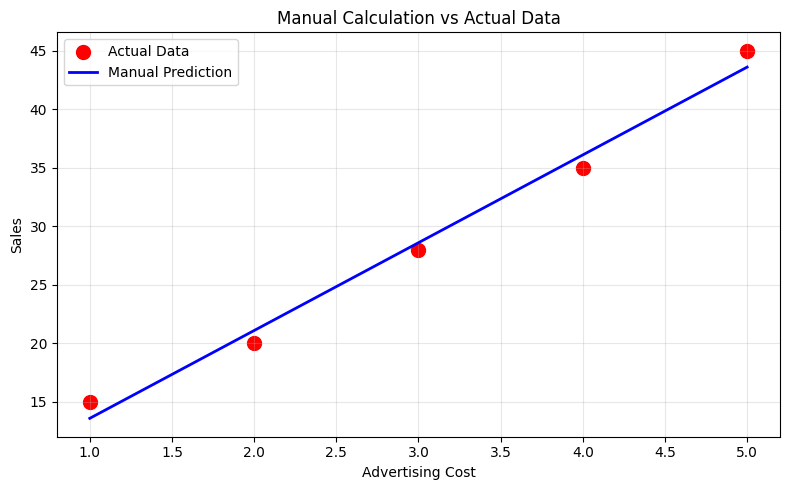

In [175]:
plt.figure(figsize=(8,5))
plt.scatter(data['advertising cost'], data['sales'], color='red', label='Actual Data', s=100)
plt.plot(data['advertising cost'], y_pred_all, color='blue', linewidth=2, label='Manual Prediction')
plt.xlabel('Advertising Cost')
plt.ylabel('Sales')
plt.title('Manual Calculation vs Actual Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## USING SKLEARN

In [176]:
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

In [177]:
data = pd.read_csv('SLR_data.csv')
data.head()

,advertising cost,sales
0,1,15
1,2,20
2,3,28
3,4,35
4,5,45


In [178]:
data.describe()

,advertising cost,sales
count,5.000000,5.000000
mean,3.000000,28.600000
std,1.581139,11.928956
min,1.000000,15.000000
25%,2.000000,20.000000
50%,3.000000,28.000000
75%,4.000000,35.000000
max,5.000000,45.000000


In [179]:
x = data.drop('sales', axis=1)
y = data['sales']

In [180]:
model_all = LinearRegression()
model_all.fit(x, y)
y_pred_all_sklearn = model_all.predict(x)

In [181]:
print(model_all.intercept_)
print(model_all.coef_)

6.099999999999998
[7.5]


In [182]:
print(y_pred_all_sklearn)

[13.6 21.1 28.6 36.1 43.6]


In [183]:
x_test = 9
y_pred = model_all.predict([[x_test]])
print(y_pred)

[73.6]


/home/el-system/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [184]:
mse_sklearn = mean_squared_error(y, y_pred_all_sklearn)
print(mse_sklearn)

1.3399999999999979


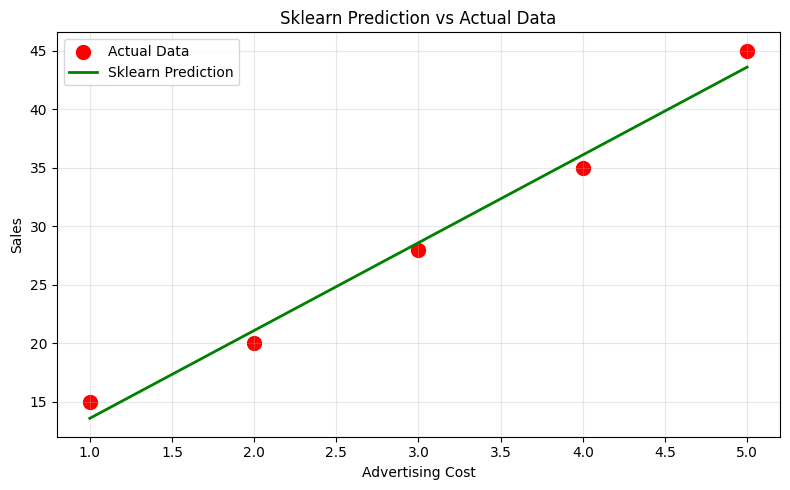

In [185]:
plt.figure(figsize=(8,5))
plt.scatter(data['advertising cost'], data['sales'], color='red', label='Actual Data', s=100)
plt.plot(data['advertising cost'], y_pred_all_sklearn, color='green', linewidth=2, label='Sklearn Prediction')
plt.xlabel('Advertising Cost')
plt.ylabel('Sales')
plt.title('Sklearn Prediction vs Actual Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# K) compare both result
## perbandingan perhitungan manual dengan python menggunakan library Sklearn

### Manual Calculation
- Rumus regresi: $y = b_0 + b_1 x$
- Koefisien manual:
- ($b_0$): 6.1
- ($b_1$): 7.5
- hasil prediksi untuk X = 9
  - $y_{pred} = 6.1 + 7.5 \times 9 = 73.6$
- rumus MSE manual dihitung dengan total sigma dari seluruh y_pred atau nilai y - rumus regresi untuk setiap kolom kemudian dibagi len(data) atau jumlah data yaitu n = 5
- MSE manual rumus MSE: $\text{MSE} = \frac{1}{n} \sum (y_{actual} - y_{pred})^2$ : **1.34**

### Sklearn Calculation
- Model: `LinearRegression` dari sklearn
- Koefisien sklearn:
- Intercept: 6.1
- Slope: 7.5
- prediksi dengan fungsi `model = LinearRegrssion()`
- hasil prediksi di X = 9
  - `model_all.predict([[9]])` = **73.6**
- MSE sklearn: **1.339**
- kalkulasi error dengan fungsi `mean_squared_error()`

**Kesimpulan:**
- perhitungan manual maupun sklearn menghasilkan hasil prediksi di saat X = 9 sebesar **73.6** dan MSE manual **1.34** dan sklearn **1.339** 